> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

# 2D Axisymmetric Heat Diffusion — Mole Perturbation (Inverse Problem)

The geometry, coordinate system, governing PDE, domain, and boundary conditions are identical to the forward notebook. The only change is the same shift made in the 1D case: $\kappa$ is no longer fixed. It is a trainable parameter that the network must recover from the data.

---

## The Leap from Forward to Inverse

In the forward notebook, $\kappa = 3.93 \times 10^{-8}$ m²/s was handed to the physics residual and held frozen. The network only had to learn $T(r, z, t)$. That run was a validation exercise — checking that the 2D cylindrical setup was physically sensible before trusting it with a harder question.

This notebook poses that harder question. The boundary conditions are the same real InSight measurements. The PDE is the same cylindrical heat equation. But now the network must simultaneously learn the temperature field **and** find the value of $\kappa$ that allows the PDE to consistently connect all four boundaries. The physics residual is the tension that forces $\kappa$ to be meaningful — only the correct diffusivity allows the surface forcing at $z = 0$, the isothermal mole at $r = R_\text{mole}$, and the deep mean temperature at $z = z_\text{max}$ to all be satisfied by the same heat equation.

---

## Why This Model Should Do Better Than 1D

The 1D spatial average PINN recovered $\kappa \approx 6.3 \times 10^{-8}$ m²/s — confirmed to be the analytically correct answer *for that model*. The inflation relative to Spohn's value is a modelling error, not an optimisation failure. The mole's thermal fin effect pumps heat axially along its length, creating a radial temperature gradient in the surrounding soil that a 1D column model cannot represent. By modelling $T(r, z, t)$ explicitly in cylindrical coordinates, this notebook captures that perturbation. The TEM-A data, previously used as a soft data loss term somewhere inside the 1D domain, is now a hard Dirichlet condition on the mole's physical surface — the strongest possible way to incorporate it. The network is forced to find a $\kappa$ that threads the needle between the surface temperature wave and the mole's own temperature history through the full 2D cylindrical soil volume.

---

## The log(κ) Parameterisation

As in the 1D inverse notebooks, we learn $\log(\kappa)$ and recover the physical value as $\kappa = e^{\log \kappa}$. Positivity is guaranteed by construction, and the optimiser works with a number of order $-17$ rather than $10^{-8}$. The parameter is initialised at Spohn's value:

$$\log(\kappa_0) = \log(3.93 \times 10^{-8})$$

This is an informed starting point, not a neutral one. Whether the 2D model converges back to Spohn's value — or refines it — is the central scientific result of this notebook.

---

## Loss Structure

Three terms, weighted to reflect the relative confidence in each:

| Loss Term | Source | Weight |
|---|---|---|
| BC core loss | Surface RAD, deep mean, mole TEM-A Dirichlet | 50 |
| Physics loss | Cylindrical heat equation at 9000 collocation points | 1 |
| BC far loss | Neumann $\partial T / \partial r = 0$ at $r = r_\text{max}$ | 1 |

The BC weight of 50 reflects that the boundary measurements are hard physical constraints — the network must anchor to them before the interior physics shapes the solution. The printed `current kappa` at every 1000 iterations is the primary diagnostic. Watching it evolve from $3.93 \times 10^{-8}$ is watching the 2D geometry do its work.

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

R_mole = 0.0135       # Radius of the mole
r_max = 0.25          # Max distance from mole center

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)

# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)
r_bc_surface = random.uniform(key3, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max
r_bc_bottom = random.uniform(key4, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)


# Mole surface boundary (r = r_mole)

N_z_mole = 20
N_t_mole = len(ltst_mole)

z_mole_1d = jnp.linspace(z_0, z_1, N_z_mole)
t_mole_1d = jnp.array(ltst_mole)

Z_mole, T_mole_grid = jnp.meshgrid(z_mole_1d, t_mole_1d, indexing='ij')
# Z_mole shape: (20, 200), T_mole_grid shape: (20, 200)

x_bc_mole = Z_mole.flatten().reshape(-1, 1)        # (4000, 1)
t_bc_mole = T_mole_grid.flatten().reshape(-1, 1)    # (4000, 1)
r_bc_mole = jnp.ones_like(x_bc_mole) * R_mole       # (4000, 1)

# Temperature: T_mole depends only on t, not z (isothermal)
# Need to repeat temp_mole for each z point
temp_mole_arr = jnp.array(temp_mole)  # (200,)
u_bc_mole = jnp.tile(temp_mole_arr, N_z_mole).reshape(-1, 1)  # (4000, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom, t_bc_mole])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom, x_bc_mole])
r_bc = jnp.concatenate([r_bc_surface, r_bc_bottom, r_bc_mole])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom, u_bc_mole])

# Rmax boundary

key1, key7, key8 = random.split(key1, 3)
n_far = 2000

t_bc_far = random.uniform(key7, (n_far, 1), minval=0, maxval=sol_seconds)
x_bc_far = random.uniform(key8, (n_far, 1), minval=0, maxval=z_max * 0.6)

# 2. Physics collocation points (30 * 30 * 30 = 9000 points)
t_physics = random.uniform(key1, (9000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (9000, 1), minval=0, maxval=z_max)
r_physics = random.uniform(key6, (9000, 1), minval=R_mole, maxval=r_max)



# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
r_min, r_norm_max = R_mole, r_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_r(r): return ( r - r_min) / (r_norm_max - r_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
r_bc = normalize_r(r_bc)
u_bc = normalize_u(u_bc)

t_bc_far_norm = normalize_t(t_bc_far)
x_bc_far_norm = normalize_x(x_bc_far)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)
r_physics = normalize_r(r_physics)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):

    # Process all hidden layers (all but last)
    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, r_point):

    def u(t_val, x_val, r_val):
        txr_in = jnp.array([[t_val, x_val, r_val]])
        return network(params, txr_in)[0, 0]

    # Derivatives w.r.t. NORMALIZED inputs
    du_dt = grad(u, argnums=0)(t_point, x_point, r_point)
    du_dr = grad(u, argnums=2)(t_point, x_point, r_point)
    d2u_dr2 = grad(grad(u, argnums=2), argnums=2)(t_point, x_point, r_point)
    d2u_dx2 = grad(grad(u, argnums=1), argnums=1)(t_point, x_point, r_point)

    # Scale factors (physical ranges)
    dt = t_max - t_min          # 88775.244
    dz = x_max - x_min          # 0.4
    dr = r_max - R_mole          # 0.2365

    # Physical r from normalized r: r_phys = R_mole + r_norm * Δr
    r_phys = R_mole + r_point * dr

    # PDE residual (normalized form):
    # (1/κ) * (dT_n/dt_n)/Δt - (d²T_n/dr_n²)/Δr² - (1/r_phys)*(dT_n/dr_n)/Δr - (d²T_n/dz_n²)/Δz²

    kappa = jnp.exp(params['log_kappa'])
    kappa_dt = kappa * dt
    residual = (du_dt  - (d2u_dr2 / dr**2) * kappa_dt - ((1.0 / r_phys) * du_dr / dr) * kappa_dt - kappa_dt * (d2u_dx2 / dz**2))

    return residual


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0))

# Neumann boudnaries at rmax
def neumann_far_single(params, t_point, x_point):
    """∂T/∂r = 0 at r = r_max (normalized r = 1)"""
    def u(r_val):
        txr_in = jnp.array([[t_point, x_point, r_val]])
        return network(params, txr_in)[0, 0]

    du_dr = grad(u)(1.0)  # evaluate at r_norm = 1
    return du_dr

neumann_far_batch = vmap(neumann_far_single, in_axes=(None, 0, 0))



# Initialize network
key = random.PRNGKey(123)
layer_sizes = [3, 64, 64, 64, 64, 1]  # 3 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={30000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, r_bc, u_bc, t_bc_far_norm, x_bc_far_norm, t_physics, x_physics, r_physics):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        txr_bc = jnp.concatenate([t_bc, x_bc, r_bc], axis=1)

        u_pred_bc = network(params, txr_bc)
        bc_loss_core = jnp.mean((u_pred_bc - u_bc)**2)

        # Boundary condition at r_max

        du_dr_far = neumann_far_batch(params,
                                   t_bc_far_norm.ravel(),
                                   x_bc_far_norm.ravel())
        bc_loss_far = jnp.mean(du_dr_far**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(),
                                                x_physics.ravel(),
                                                r_physics.ravel(),
                                                )
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.


        return  bc_loss_core * 50 + physics_loss + bc_loss_far, (bc_loss_core, physics_loss, bc_loss_far)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 60000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Training loop
losses = []
losses_bc_core = []
losses_phys = []
losses_bc_far = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, r_bc, u_bc,
        t_bc_far_norm, x_bc_far_norm,
        t_physics, x_physics, r_physics
    )

    losses.append(loss)
    losses_bc_core.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_bc_far.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Core Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, BC Far Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")

import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc_core],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_bc_far': [float(l) for l in losses_bc_far],

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
}

with open('checkpoints_perturbance/forward_run_64x4.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

Iteration 1000/60000, Loss: 0.030457
  BC Core Loss: 0.000550, Physics Loss: 0.002871, BC Far Loss: 0.000106
  Current kappa: 3.57e-08 m^2/s
Iteration 2000/60000, Loss: 0.028162
  BC Core Loss: 0.000512, Physics Loss: 0.002541, BC Far Loss: 0.000036
  Current kappa: 3.46e-08 m^2/s
Iteration 3000/60000, Loss: 0.028145
  BC Core Loss: 0.000514, Physics Loss: 0.002409, BC Far Loss: 0.000060
  Current kappa: 3.46e-08 m^2/s
Iteration 4000/60000, Loss: 0.025737
  BC Core Loss: 0.000460, Physics Loss: 0.002605, BC Far Loss: 0.000109
  Current kappa: 3.73e-08 m^2/s
Iteration 5000/60000, Loss: 0.021829
  BC Core Loss: 0.000380, Physics Loss: 0.002640, BC Far Loss: 0.000176
  Current kappa: 4.54e-08 m^2/s
Iteration 6000/60000, Loss: 0.014894
  BC Core Loss: 0.000242, Physics Loss: 0.002644, BC Far Loss: 0.000133
  Current kappa: 4.80e-08 m^2/s
Iteration 7000/60000, Loss: 0.009509
  BC Core Loss: 0.000148, Physics Loss: 0.002082, BC Far Loss: 0.000049
  Current kappa: 3.72e-08 m^2/s
Iteration 800

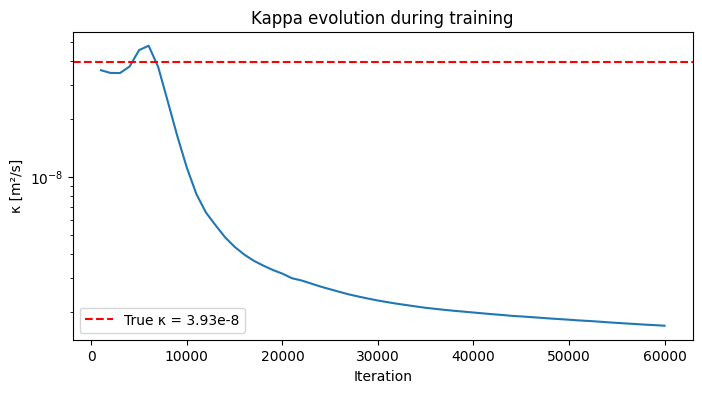

Final kappa: 1.690e-09
True kappa:  3.93e-8


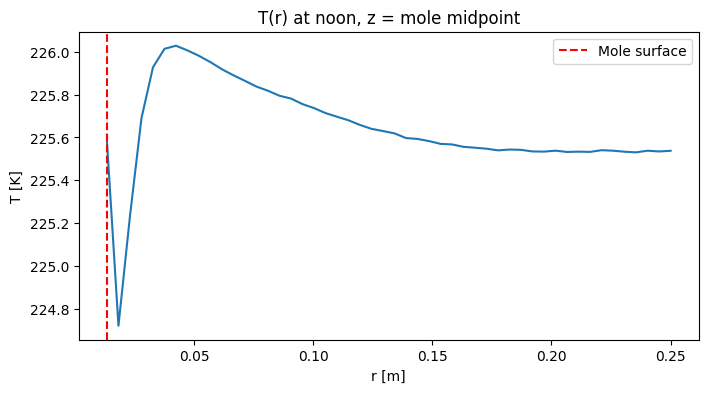

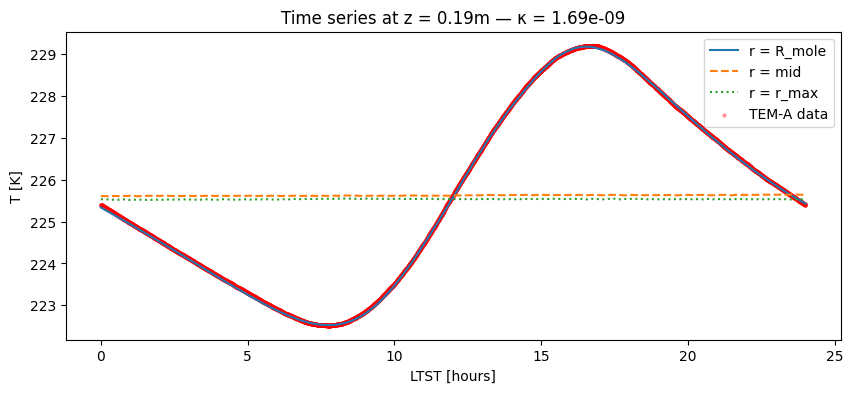

In [ ]:
# --- 0. Kappa trajectory ---
kappa_history = [float(jnp.exp(s['log_kappa'])) for s in snapshots]
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(snapshot_iterations, kappa_history)
ax.axhline(3.93e-8, color='r', linestyle='--', label='True κ = 3.93e-8')
ax.set_xlabel('Iteration')
ax.set_ylabel('κ [m²/s]')
ax.set_title('Kappa evolution during training')
ax.legend()
plt.show()
print(f"Final kappa: {float(jnp.exp(params['log_kappa'])):.3e}")
print(f"True kappa:  3.93e-8")

# --- 1. T(r) at noon — is there any radial diffusion? ---
r_test = jnp.linspace(0, 1, 50).reshape(-1, 1)
t_noon = jnp.ones_like(r_test) * 0.5
z_mole_norm = normalize_x((z_0 + z_1) / 2)
z_in = jnp.ones_like(r_test) * z_mole_norm

txr_test = jnp.concatenate([t_noon, z_in, r_test], axis=1)
T_pred = unnormalize_u(network(params, txr_test))

plt.figure(figsize=(8, 4))
plt.plot(np.array(r_test * (r_max - R_mole) + R_mole), np.array(T_pred))
plt.xlabel('r [m]')
plt.ylabel('T [K]')
plt.title('T(r) at noon, z = mole midpoint')
plt.axvline(R_mole, color='r', linestyle='--', label='Mole surface')
plt.legend()
plt.show()

# --- 2. Time series at mole depth — does far-field still have diurnal signal? ---
t_line = jnp.linspace(0, 1, 200).reshape(-1, 1)
z_in = jnp.ones_like(t_line) * z_mole_norm

fig, ax = plt.subplots(figsize=(10, 4))
for r_val, style, name in [(0.0, '-', 'r = R_mole'), (0.5, '--', 'r = mid'), (1.0, ':', 'r = r_max')]:
    r_in = jnp.ones_like(t_line) * r_val
    txr = jnp.concatenate([t_line, z_in, r_in], axis=1)
    T_pred = unnormalize_u(network(params, txr))
    ax.plot(np.array(t_line * 24), np.array(T_pred), style, label=name)

ax.scatter(np.array(jnp.array(ltst_mole) * 24 / sol_seconds), temp_mole,
           s=5, alpha=0.3, c='red', label='TEM-A data')
ax.set_xlabel('LTST [hours]')
ax.set_ylabel('T [K]')
ax.set_title(f'Time series at z = {(z_0+z_1)/2:.2f}m — κ = {float(jnp.exp(params["log_kappa"])):.2e}')
ax.legend()
plt.show()

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_min = 0             # surface
z_max = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

R_mole = 0.0135       # Radius of the mole
r_max = 0.25          # Max distance from mole center

z_0 = 0.017           # Top of mole
z_1 = 0.363           # bottom of mole

avg_bottom_temp = 225.6  # average bottom temperature (K)


# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


key = random.PRNGKey(0)
key, key1, key2, key3, key4, key5, key6 = random.split(key, 7)

# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)
r_bc_surface = random.uniform(key3, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = random.uniform(key5, (n_surface, 1), minval=0, maxval=sol_seconds) # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * z_max
r_bc_bottom = random.uniform(key4, (n_surface, 1), minval=R_mole, maxval=r_max)

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)


# Mole surface boundary (r = r_mole)

N_z_mole = 20
N_t_mole = len(ltst_mole)

z_mole_1d = jnp.linspace(z_0, z_1, N_z_mole)
t_mole_1d = jnp.array(ltst_mole)

Z_mole, T_mole_grid = jnp.meshgrid(z_mole_1d, t_mole_1d, indexing='ij')
# Z_mole shape: (20, 200), T_mole_grid shape: (20, 200)

x_bc_mole = Z_mole.flatten().reshape(-1, 1)        # (4000, 1)
t_bc_mole = T_mole_grid.flatten().reshape(-1, 1)    # (4000, 1)
r_bc_mole = jnp.ones_like(x_bc_mole) * R_mole       # (4000, 1)

# Temperature: T_mole depends only on t, not z (isothermal)
# Need to repeat temp_mole for each z point
temp_mole_arr = jnp.array(temp_mole)  # (200,)
u_bc_mole = jnp.tile(temp_mole_arr, N_z_mole).reshape(-1, 1)  # (4000, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom, t_bc_mole])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom, x_bc_mole])
r_bc = jnp.concatenate([r_bc_surface, r_bc_bottom, r_bc_mole])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom, u_bc_mole])

# Rmax boundary

key1, key7, key8 = random.split(key1, 3)
n_far = 2000

t_bc_far = random.uniform(key7, (n_far, 1), minval=0, maxval=sol_seconds)
x_bc_far = random.uniform(key8, (n_far, 1), minval=0, maxval=z_max * 0.6)

# 2. Physics collocation points (30 * 30 * 30 = 9000 points)
t_physics = random.uniform(key1, (9000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (9000, 1), minval=0, maxval=z_max)
r_physics = random.uniform(key6, (9000, 1), minval=R_mole, maxval=r_max)



# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_max
r_min, r_norm_max = R_mole, r_max
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_r(r): return ( r - r_min) / (r_norm_max - r_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
r_bc = normalize_r(r_bc)
u_bc = normalize_u(u_bc)

t_bc_far_norm = normalize_t(t_bc_far)
x_bc_far_norm = normalize_x(x_bc_far)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)
r_physics = normalize_r(r_physics)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):

    # Process all hidden layers (all but last)
    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, r_point):

    def u(t_val, x_val, r_val):
        txr_in = jnp.array([[t_val, x_val, r_val]])
        return network(params, txr_in)[0, 0]

    # Derivatives w.r.t. NORMALIZED inputs
    du_dt = grad(u, argnums=0)(t_point, x_point, r_point)
    du_dr = grad(u, argnums=2)(t_point, x_point, r_point)
    d2u_dr2 = grad(grad(u, argnums=2), argnums=2)(t_point, x_point, r_point)
    d2u_dx2 = grad(grad(u, argnums=1), argnums=1)(t_point, x_point, r_point)

    # Scale factors (physical ranges)
    dt = t_max - t_min          # 88775.244
    dz = x_max - x_min          # 0.4
    dr = r_max - R_mole          # 0.2365

    # Physical r from normalized r: r_phys = R_mole + r_norm * Δr
    r_phys = R_mole + r_point * dr

    # PDE residual (divided by κ, your week 8 trick):
    # (1/κ) * (dT_n/dt_n)/Δt - (d²T_n/dr_n²)/Δr² - (1/r_phys)*(dT_n/dr_n)/Δr - (d²T_n/dz_n²)/Δz²

    kappa = jnp.exp(params['log_kappa'])
    kappa_dt = kappa * dt
    residual = (du_dt  - (d2u_dr2 / dr**2) * kappa_dt - ((1.0 / r_phys) * du_dr / dr) * kappa_dt - kappa_dt * (d2u_dx2 / dz**2))

    return residual


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0))

# Neumann boudnaries at rmax
def neumann_far_single(params, t_point, x_point):
    """∂T/∂r = 0 at r = r_max (normalized r = 1)"""
    def u(r_val):
        txr_in = jnp.array([[t_point, x_point, r_val]])
        return network(params, txr_in)[0, 0]

    du_dr = grad(u)(1.0)  # evaluate at r_norm = 1
    return du_dr

neumann_far_batch = vmap(neumann_far_single, in_axes=(None, 0, 0))



# Fresh network — no physics ever touches this
key = random.PRNGKey(123)
layer_sizes = [3, 64, 64, 64, 64, 1]
params = init_network_params(layer_sizes, key)

# Remove log_kappa during phase 1 — not needed
network_params = params['network']

optimizer_p1 = optax.adam(1e-3)
opt_state_p1 = optimizer_p1.init(network_params)

@jit
def update_bc_only(network_params, opt_state,
                   t_bc, x_bc, r_bc, u_bc,
                   t_far_norm, x_far_norm):
    def loss_fn(network_params):
        # Wrap in params dict so network() works
        p = {'network': network_params, 'log_kappa': jnp.array(0.0)}  # dummy

        txr_bc = jnp.concatenate([t_bc, x_bc, r_bc], axis=1)
        bc_core = jnp.mean((network(p, txr_bc) - u_bc)**2)

        du_dr_far = neumann_far_batch(p, t_far_norm.ravel(), x_far_norm.ravel())
        bc_far = jnp.mean(du_dr_far**2)

        return bc_core * 50 + bc_far * 10, (bc_core, bc_far)

    (loss, aux), grads = jax.value_and_grad(loss_fn, has_aux=True)(network_params)
    updates, new_opt = optimizer_p1.update(grads, opt_state, network_params)
    new_params = optax.apply_updates(network_params, updates)
    return new_params, new_opt, loss, aux

print("=== PHASE 1: BC-only training ===")
for i in range(30000):
    network_params, opt_state_p1, loss, aux = update_bc_only(
        network_params, opt_state_p1,
        t_bc, x_bc, r_bc, u_bc,
        t_bc_far_norm, x_bc_far_norm)
    if (i+1) % 5000 == 0:
        print(f"Iter {i+1}, Loss: {loss:.6f}, BC core: {aux[0]:.3e}, BC far: {aux[1]:.3e}")


# Start kappa deliberately wrong
log_kappa = jnp.log(4e-7)  # 10x too high

optimizer_p2 = optax.adam(1e-2)
opt_state_p2 = optimizer_p2.init(log_kappa)

# Build frozen params dict
frozen_params = {'network': network_params, 'log_kappa': log_kappa}

@jit
def update_kappa_only(log_kappa, opt_state, frozen_network,
                      t_phys, x_phys, r_phys):
    def loss_fn(log_kappa):
        p = {'network': frozen_network, 'log_kappa': log_kappa}
        residuals = physics_residual_batch(p,
                                           t_phys.ravel(),
                                           x_phys.ravel(),
                                           r_phys.ravel())
        return jnp.mean(residuals**2)

    loss, grads = jax.value_and_grad(loss_fn)(log_kappa)
    updates, new_opt = optimizer_p2.update(grads, opt_state, log_kappa)
    new_log_kappa = optax.apply_updates(log_kappa, updates)
    return new_log_kappa, new_opt, loss

print("\n=== PHASE 2: Kappa-only optimization ===")
print(f"Starting kappa: {jnp.exp(log_kappa):.3e}")

kappa_history = []
kappa_losses = []

for i in range(10000):
    log_kappa, opt_state_p2, loss = update_kappa_only(
        log_kappa, opt_state_p2, network_params,
        t_physics, x_physics, r_physics)

    if (i+1) % 1000 == 0:
        k = float(jnp.exp(log_kappa))
        kappa_history.append(k)
        kappa_losses.append(float(loss))
        print(f"Iter {i+1}, Physics loss: {loss:.6e}, κ: {k:.3e}")

print(f"\nFinal kappa: {float(jnp.exp(log_kappa)):.4e}")
print(f"True kappa:  3.930e-8")
print(f"Ratio:       {float(jnp.exp(log_kappa))/3.93e-8:.2f}x")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


=== PHASE 1: BC-only training ===
Iter 5000, Loss: 0.006403, BC core: 1.248e-04, BC far: 1.617e-05
Iter 10000, Loss: 0.001599, BC core: 3.158e-05, BC far: 2.008e-06
Iter 15000, Loss: 0.000543, BC core: 1.067e-05, BC far: 9.132e-07
Iter 20000, Loss: 0.000072, BC core: 1.342e-06, BC far: 5.276e-07
Iter 25000, Loss: 0.000124, BC core: 2.442e-06, BC far: 2.041e-07
Iter 30000, Loss: 0.000059, BC core: 1.133e-06, BC far: 2.358e-07

=== PHASE 2: Kappa-only optimization ===
Starting kappa: 4.000e-07
Iter 1000, Physics loss: 4.970687e+00, κ: 4.130e-08
Iter 2000, Physics loss: 1.983035e+00, κ: 2.241e-08
Iter 3000, Physics loss: 1.237774e+00, κ: 1.471e-08
Iter 4000, Physics loss: 9.375051e-01, κ: 1.035e-08
Iter 5000, Physics loss: 7.889269e-01, κ: 7.523e-09
Iter 6000, Physics loss: 7.068535e-01, κ: 5.541e-09
Iter 7000, Physics loss: 6.584647e-01, κ: 4.097e-09
Iter 8000, Physics loss: 6.286409e-01, κ: 3.021e-09
Iter 9000, Physics loss: 6.097338e-01, κ: 2.212e-09
Iter 10000, Physics loss: 5.974795e

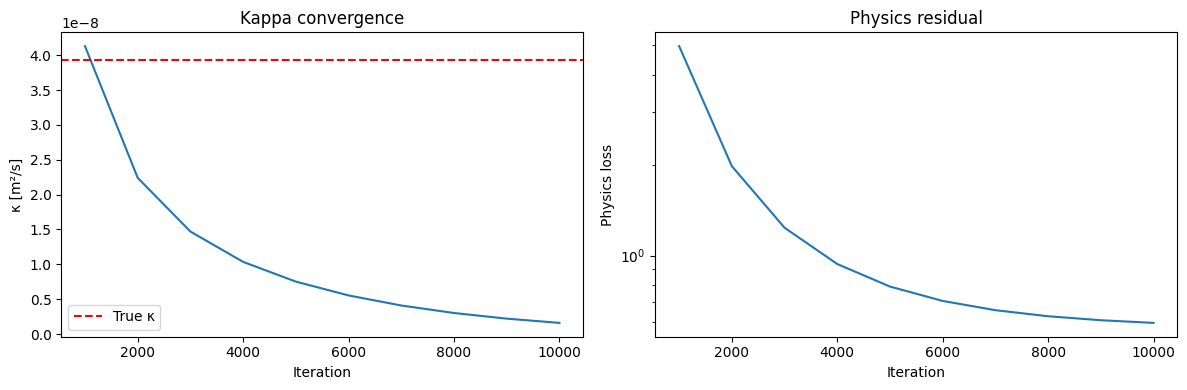

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1000, 10001, 1000), kappa_history)
axes[0].axhline(3.93e-8, color='r', linestyle='--', label='True κ')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ [m²/s]')
axes[0].set_title('Kappa convergence')
axes[0].legend()

axes[1].semilogy(range(1000, 10001, 1000), kappa_losses)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Physics loss')
axes[1].set_title('Physics residual')
plt.tight_layout()
plt.show()